# Hypothesis Testing

EDA에서 확인한 지연 분포 특성을 바탕으로 배송 지연이 고객 이탈에 미치는 영향을 검증한다.   
지연 데이터는 Shapiro-Wilk 검정(p=0.0000)에서 정규분포를 따르지 않는 것으로 확인되었으므로   
초기 설계(hypothesis.md)에서 계획한 t-test 대신 비모수 검정인 Mann-Whitney U test를 사용한다.   

- H1: 3일 지연은 이탈 위험에 유의미한 영향을 주지 않는다
- H2: 지연 경험 고객은 정상 배송 고객보다 이탈 위험이 높다
- H3: 배송 지연으로 인한 예상 매출 손실은 전체 매출의 5% 이상일 것이다
- H4: 배송 지연이 길어질수록 주문 취소율이 증가한다

분석에 필요한 세 테이블을 로드한 뒤 가설 검증용 데이터를 준비한다.   

- 배송일 또는 예상 배송일이 없는 주문(2,965건)은 지연 일수 계산이    
  불가능하므로 제외한다.
- 동일 주문에 리뷰가 여러 개인 경우 MIN(review_score)를 사용한다.    
  가장 부정적인 경험이 이탈 위험을 결정한다고 판단했기 때문이다.
- 이탈 위험 고객(is_at_risk)은 별점 1~2점으로 정의한다.    
  실제 재구매 데이터가 없으므로 낮은 별점을 이탈 가능성의 proxy로 활용한다.
- delay_days > 0인 경우만 지연으로 정의한다.    
  (EDA에서 전체의 93.2%가 조기 배송임을 확인)
- order_level로 집계하는 이유: 한 주문에 여러 리뷰가 있을 경우    
  is_at_risk=max로 취합하여 주문 단위 분석을 보장한다.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import sys
import os

sys.path.append(os.path.abspath('..'))

from etl.db import engine

In [2]:
orders = pd.read_sql('SELECT * FROM orders', engine)
reviews = pd.read_sql('SELECT * FROM reviews', engine)
payments = pd.read_sql('SELECT * FROM payments', engine)

print(orders.shape)
print(reviews.shape)
print(payments.shape)
print()
print(orders.columns.tolist())
print(reviews.columns.tolist())
print(payments.columns.tolist())

(99441, 8)
(98410, 7)
(103886, 5)

['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']
['review_id', 'order_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp']
['order_id', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value']


In [3]:
# Calculate delay days
delivered = orders.dropna(subset=[
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]).copy()

delivered['delay_days'] = (
    delivered['order_delivered_customer_date'] -
    delivered['order_estimated_delivery_date']
).dt.days

# Merge with review score
review_agg = reviews.groupby('order_id')['review_score'].min().reset_index()

merged = delivered[['order_id', 'delay_days']].merge(
    review_agg, on='order_id', how='left'
)

# Define at-risk customer (proxy for churn)
merged['is_at_risk'] = (merged['review_score'] <= 2).astype(int)


# Define delay buckets
merged['delay_group'] = pd.cut(
    merged['delay_days'],
    bins=[-150, 0, 3, 7, 14, 200],
    labels=['on_time', 'slight(1~3)', 'moderate(3~7)', 'severe(7~14)', 'extreme(14+)']
)

# Organize by order level
order_level = merged.groupby('order_id').agg({
    'delay_days': 'first',        
    'is_at_risk': 'max'           
}).reset_index()

order_level['delay_group'] = pd.cut(
    order_level['delay_days'],
    bins=[-150, 0, 3, 7, 14, 200],
    labels=['on_time', 'slight(1~3)', 'moderate(3~7)', 'severe(7~14)', 'extreme(14+)']
)

order_level['delivery_group'] = order_level['delay_days'].apply(
    lambda x: 'delayed' if x > 0 else 'on_time'
)

print(f"order_level: {order_level.shape}")
print(order_level['delay_group'].value_counts().sort_index())

order_level: (96476, 5)
delay_group
on_time          89941
slight(1~3)       1870
moderate(3~7)     1802
severe(7~14)      1479
extreme(14+)      1384
Name: count, dtype: int64


## H1 — Delivery Delay Threshold

3일 이내 지연이 이탈 위험에 유의미한 영향을 주지 않는지 검증한다.   
on_time 그룹과 slight(1~3일) 그룹의 이탈 위험 비율을 비교하여   
고객이 허용하는 지연 임계값을 찾는다.

통계적으로 유의미한 차이가 없다면(p > 0.05)   
3일은 허용 가능한 지연 범위로 판단할 수 있다.

지연 구간별 이탈 위험 비율을 집계하여    
on_time 그룹과 slight(1~3일) 그룹 간 차이를 확인한다.

In [4]:
# Group stats
group_stats = order_level.groupby('delay_group', observed=True).agg(
    order_count=('order_id', 'count'),
    at_risk_count=('is_at_risk', 'sum'),
    at_risk_ratio=('is_at_risk', 'mean')
).reset_index()

group_stats['at_risk_ratio'] = (group_stats['at_risk_ratio'] * 100).round(2)

print(group_stats.to_string(index=False))

  delay_group  order_count  at_risk_count  at_risk_ratio
      on_time        89941           8217           9.14
  slight(1~3)         1870            590          31.55
moderate(3~7)         1802           1176          65.26
 severe(7~14)         1479           1154          78.03
 extreme(14+)         1384           1041          75.22


on_time과 slight(1~3일) 그룹의 이탈 위험 비율 차이가 통계적으로    
유의미한지 검정한다.

귀무가설(H0): 두 그룹의 이탈 위험 비율에 차이가 없다.   
양측 검정(two-sided)을 사용한다.

In [5]:
# Mann-Whitney U test: on_time vs slight(1~3)
on_time = order_level[order_level['delay_group'] == 'on_time']['is_at_risk'].dropna()
slight = order_level[order_level['delay_group'] == 'slight(1~3)']['is_at_risk'].dropna()

stat, p = stats.mannwhitneyu(on_time, slight, alternative='two-sided')

print("=== H1: on_time vs slight(1~3) ===")
print(f"on_time  — count: {len(on_time)}, at_risk_ratio: {on_time.mean()*100:.2f}%")
print(f"slight   — count: {len(slight)}, at_risk_ratio: {slight.mean()*100:.2f}%")
print(f"statistic: {stat:.4f}")
print(f"p-value  : {p:.4f}")

if p < 0.05:
    print("result: significant difference -> reject H0 (no difference)")
else:
    print("result: no significant difference -> fail to reject H0")

=== H1: on_time vs slight(1~3) ===
on_time  — count: 89941, at_risk_ratio: 9.14%
slight   — count: 1870, at_risk_ratio: 31.55%
statistic: 65245135.0000
p-value  : 0.0000
result: significant difference -> reject H0 (no difference)


구간별 이탈 위험 비율을 시각화하여 지연 일수에 따른 변화 패턴을 확인한다.   
on_time 기준선 대비 각 구간의 상승폭을 직관적으로 파악할 수 있다.

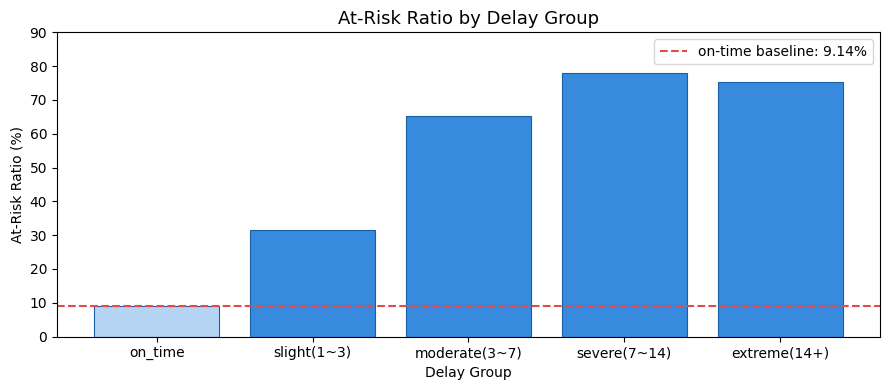

In [6]:
baseline = group_stats.query("delay_group == 'on_time'")['at_risk_ratio'].values[0]

fig, ax = plt.subplots(figsize=(9, 4))
colors = ['#B5D4F4' if g == 'on_time' else '#378ADD'
          for g in group_stats['delay_group'].astype(str)]
bars = ax.bar(group_stats['delay_group'].astype(str),
              group_stats['at_risk_ratio'],
              color=colors, edgecolor='#185FA5', linewidth=0.8)
ax.axhline(baseline, color='#E24B4A', linestyle='--', linewidth=1.5,
           label=f'on-time baseline: {baseline:.2f}%')
ax.set_title('At-Risk Ratio by Delay Group', fontsize=13)
ax.set_xlabel('Delay Group')
ax.set_ylabel('At-Risk Ratio (%)')
ax.set_ylim(0, 90)
ax.legend()
plt.tight_layout()
plt.show()

**결과: H1 기각**

on_time(9.14%) 대비 slight(31.55%)에서 이탈 위험 비율이 이미 3배 이상    
높게 나타났으며, p < 0.0001로 통계적으로 유의미하다.

3일 이내 지연도 허용 가능한 범위가 아니다.   
고객은 예상보다 짧은 지연에도 민감하게 반응하는 것으로 보인다.   
이 결과는 SLA 기준을 3일보다 더 엄격하게 설정해야 함을 시사한다.

## H2 — Repurchase Rate Drop

H1에서 임계값을 확인한 후, 지연 여부 자체가 이탈 위험에 미치는    
영향을 검증한다. 지연 경험 고객(delayed)과 정상 배송 고객(on_time)을    
두 그룹으로 나눠 비교한다. 

지연이 실제 이탈로 이어진다면 SLA 기준 설정의 근거가 된다.

In [7]:
# Define delayed vs on_time group
h2_stats = order_level.groupby('delivery_group').agg(
    order_count=('order_id', 'count'),
    at_risk_count=('is_at_risk', 'sum'),
    at_risk_ratio=('is_at_risk', 'mean')
).reset_index()

h2_stats['at_risk_ratio'] = (h2_stats['at_risk_ratio'] * 100).round(2)

print(h2_stats.to_string(index=False))

delivery_group  order_count  at_risk_count  at_risk_ratio
       delayed         6535           3961          60.61
       on_time        89941           8217           9.14


지연 그룹이 정상 배송 그룹보다 이탈 위험 비율이 높은지 검정한다.

귀무가설(H0): 두 그룹의 이탈 위험 비율에 차이가 없다.   
단측 검정(alternative='less')을 사용한다.   
on_time 그룹의 이탈 위험이 delayed 그룹보다 낮다는 방향성을 검정하는 것이다.

In [8]:
# Mann-Whitney U test: on_time vs delayed
on_time_h2 = order_level[order_level['delivery_group'] == 'on_time']['is_at_risk'].dropna()
delayed_h2 = order_level[order_level['delivery_group'] == 'delayed']['is_at_risk'].dropna()

stat, p = stats.mannwhitneyu(on_time_h2, delayed_h2, alternative='less')

print("=== H2: on_time vs delayed ===")
print(f"on_time — count: {len(on_time_h2)}, at_risk_ratio: {on_time_h2.mean()*100:.2f}%")
print(f"delayed — count: {len(delayed_h2)}, at_risk_ratio: {delayed_h2.mean()*100:.2f}%")
print(f"statistic: {stat:.4f}")
print(f"p-value  : {p:.4f}")

if p < 0.05:
    print("result: delayed group has significantly higher at-risk ratio -> H2 supported")
else:
    print("result: no significant difference -> H2 rejected")

=== H2: on_time vs delayed ===
on_time — count: 89941, at_risk_ratio: 9.14%
delayed — count: 6535, at_risk_ratio: 60.61%
statistic: 142603114.5000
p-value  : 0.0000
result: delayed group has significantly higher at-risk ratio -> H2 supported


(one-sided test: delayed > on_time)

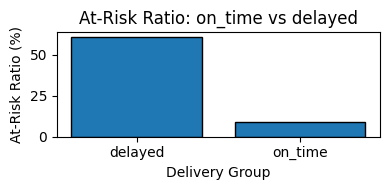

In [9]:
plt.figure(figsize=(4, 2))
plt.bar(h2_stats['delivery_group'], h2_stats['at_risk_ratio'], edgecolor='black')
plt.title('At-Risk Ratio: on_time vs delayed')
plt.xlabel('Delivery Group')
plt.ylabel('At-Risk Ratio (%)')
plt.tight_layout()
plt.show()

**결과: H2 채택**

지연 경험 고객의 이탈 위험 비율은 60.61%로, 정상 배송 고객(9.14%) 대비   
6.6배 높다. p < 0.0001로 통계적으로 유의미하다.

배송 지연은 고객 만족에 직접적인 영향을 주며   
이탈 위험 감소를 위해 배송 지연 자체를 줄이는 것이 핵심 과제임을 확인했다.

## H3 — Revenue Loss Estimation

H2에서 이탈 위험 고객 수를 확인한 후, 배송 지연으로 인한 매출 손실을 수치화한다.   

초기 설계(hypothesis.md)에서는 이탈 위험 고객 수 × ARPU로 손실을 추정하려 했으나      
실제 결제 데이터가 존재하므로 추정 대신 실측값 기반으로 계산 방식을 변경했다.   
이 방식이 더 보수적이고 근거가 명확하다.   

계산 방식:
- 지연 주문 중 is_at_risk=1인 고객의 실제 결제 금액 합산 = 예상 손실   
- 예상 손실 / 전체 매출 = 손실 비율
- 판단 기준을 5%로 설정한 이유:   
  at_risk는 실제 이탈자가 아닌 proxy 지표이므로 과대 추정을 경계하기 위해   
  보수적인 기준점을 적용했다. 전수 조사보다 위험도가 가장 높은 세그먼트를   
  먼저 식별하여 한정된 운영 리소스의 우선순위를 결정하기 위한 전략적 선택이다.

※ is_at_risk는 실제 이탈이 아닌 proxy 지표이므로   
리뷰를 남기지 않은 불만족 고객이 포함되지 않았을 가능성이 있다.   
실제 손실은 더 클 수 있다.

In [10]:
valid_orders = set(order_level['order_id'])

order_revenue = payments.groupby('order_id')['payment_value'].sum().reset_index()
order_revenue.columns = ['order_id', 'order_revenue']

order_revenue = order_revenue[order_revenue['order_id'].isin(valid_orders)]

merged_rev = order_level.merge(order_revenue, on='order_id', how='inner')

total_revenue = merged_rev['order_revenue'].sum()

at_risk_revenue = merged_rev[
    (merged_rev['delivery_group'] == 'delayed') &
    (merged_rev['is_at_risk'] == 1)
]['order_revenue'].sum()

arpu = merged_rev['order_revenue'].mean()

loss_ratio = at_risk_revenue / total_revenue * 100

print("=== H3: Revenue Loss Estimation ===")
print(f"total_revenue    : {total_revenue:,.2f} BRL")
print(f"at_risk_revenue  : {at_risk_revenue:,.2f} BRL")
print(f"loss_ratio       : {loss_ratio:.2f}%")
print(f"arpu             : {arpu:.2f} BRL")

if loss_ratio >= 5:
    print("result: loss ratio >= 5% -> improvement required -> H3 supported")
else:
    print("result: loss ratio < 5% -> within acceptable range -> H3 rejected")

=== H3: Revenue Loss Estimation ===
total_revenue    : 15,421,831.43 BRL
at_risk_revenue  : 717,517.62 BRL
loss_ratio       : 4.65%
arpu             : 159.85 BRL
result: loss ratio < 5% -> within acceptable range -> H3 rejected


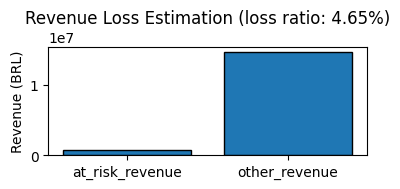

In [11]:
labels = ['at_risk_revenue', 'other_revenue']
values = [at_risk_revenue, total_revenue - at_risk_revenue]

plt.figure(figsize=(4, 2))
plt.bar(labels, values, edgecolor='black')
plt.title(f'Revenue Loss Estimation (loss ratio: {loss_ratio:.2f}%)')
plt.ylabel('Revenue (BRL)')
plt.tight_layout()
plt.show()

**결과: H3 기각 (기준치 근접)**

손실 비율 4.65%로 사전 기준(5%)에 미달하여 형식적으로는 기각된다.   
그러나 proxy 지표의 특성상 실제 손실은 더 클 수 있으며   
무시하기 어려운 수준의 잠재적 매출 손실이 존재한다.

## H4 — Cancellation Rate by Delay

배송 지연이 길어질수록 주문 취소율이 단조 증가하는지 검증한다.   

데이터 구조상 한계가 있다. 취소 주문은 배송 완료 데이터가 없어   
delay_days 계산이 불가능하다. 초기 설계에서는 배송 지연 일수를   
기준으로 분석하려 했으나, 대안으로 expected_wait_days   
(주문일 ~ 예상 배송일)를 기준으로 분석한다.   

따라서 이 분석은 실제 지연과 취소의 관계가 아니라   
고객이 인지한 배송 대기 시간과 취소 행동 간의 관계를 반영한다.

In [12]:
# Calculate expected wait days from purchase to estimated delivery
orders['expected_wait_days'] = (
    orders['order_estimated_delivery_date'] -
    orders['order_purchase_timestamp']
).dt.days

orders['is_canceled'] = (orders['order_status'] == 'canceled').astype(int)

# Drop rows where expected_wait_days is null
orders_wait = orders.dropna(subset=['expected_wait_days']).copy()

# Bucket by expected wait days
orders_wait['wait_group'] = pd.cut(
    orders_wait['expected_wait_days'],
    bins=[0, 10, 20, 30, 40, 200],
    labels=['~10d', '~20d', '~30d', '~40d', '40d+']
)

h4_stats = orders_wait.groupby('wait_group', observed=True).agg(
    order_count=('order_id', 'count'),
    canceled_count=('is_canceled', 'sum'),
    cancel_rate=('is_canceled', 'mean')
).reset_index()

h4_stats['cancel_rate'] = (h4_stats['cancel_rate'] * 100).round(2)

print("=== H4: Cancellation Rate by Expected Wait Days ===")
print(h4_stats.to_string(index=False))

=== H4: Cancellation Rate by Expected Wait Days ===
wait_group  order_count  canceled_count  cancel_rate
      ~10d         5352              58         1.08
      ~20d        30992             243         0.78
      ~30d        45422             224         0.49
      ~40d        14242              65         0.46
      40d+         3433              35         1.02


예상 대기일 구간과 취소율 간의 단조 관계를 Spearman 상관계수로 검정한다.   
Pearson 상관계수는 선형 관계를 가정하지만   
Spearman은 순위 기반이므로 비선형 단조 관계도 포착할 수 있다.

In [13]:
# Spearman correlation between wait group rank and cancellation rate
wait_group_order = ['~10d', '~20d', '~30d', '~40d', '40d+']
wait_rank_map = {g: i for i, g in enumerate(wait_group_order)}
h4_stats['group_rank'] = h4_stats['wait_group'].astype(str).map(wait_rank_map)

corr, p = stats.spearmanr(h4_stats['group_rank'], h4_stats['cancel_rate'])

print("=== H4: Spearman Correlation Test ===")
print(f"Spearman r : {corr:.4f}")
print(f"p-value    : {p:.4f}")

if p < 0.05 and corr > 0:
    print("result: cancel rate increases with expected wait days -> H4 supported")
else:
    print("result: no significant monotonic correlation -> H4 rejected")

=== H4: Spearman Correlation Test ===
Spearman r : -0.4000
p-value    : 0.5046
result: no significant monotonic correlation -> H4 rejected


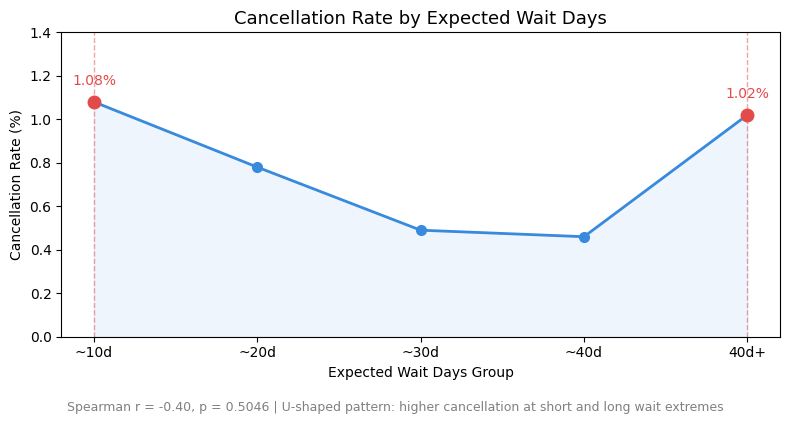

In [14]:
fig, ax = plt.subplots(figsize=(8, 4))
x = range(len(h4_stats))
labels = h4_stats['wait_group'].astype(str).tolist()
rates = h4_stats['cancel_rate'].tolist()

ax.plot(labels, rates, color='#378ADD', linewidth=2,
        marker='o', markersize=7, zorder=3)

for i in [0, -1]:
    ax.plot(labels[i], rates[i], 'o', color='#E24B4A', markersize=9, zorder=4)
    ax.annotate(f'{rates[i]:.2f}%', xy=(labels[i], rates[i]),
                xytext=(0, 12), textcoords='offset points',
                ha='center', fontsize=10, color='#E24B4A')
    ax.axvline(x=i % len(labels), color='#E24B4A', linestyle='--',
               linewidth=1, alpha=0.5)

ax.fill_between(labels, rates, alpha=0.08, color='#378ADD')
ax.set_title('Cancellation Rate by Expected Wait Days', fontsize=13)
ax.set_xlabel('Expected Wait Days Group')
ax.set_ylabel('Cancellation Rate (%)')
ax.set_ylim(0, 1.4)
fig.text(0.5, -0.04,
         'Spearman r = -0.40, p = 0.5046 | U-shaped pattern: higher cancellation at short and long wait extremes',
         ha='center', fontsize=9, color='gray')
plt.tight_layout()
plt.show()

**결과: H4 기각**

Spearman r = -0.40, p = 0.5046으로 단조 증가 패턴은 확인되지 않았다.   

대신 10일 이하 단기(1.08%)와 40일 초과 장기(1.02%) 구간에서   
취소율이 상대적으로 높은 U자형 패턴이 관찰되었다.   
이는 단순 지연이 아니라 고객의 기대 배송 경험이 취소 행동에 영향을 줄 수 있음을 시사한다.   

단, H4는 데이터 구조 한계로 인해 실제 지연이 아닌 예상 대기일 기준으로 분석되었으며   
취소 건수 자체가 전체의 0.63% 수준으로 제한적이므로 해석에 주의가 필요하다.

## Hypothesis Testing Summary

| 가설 | 결과 | 수치 | 판단 |
|------|------|------|------|
| H1 | 기각 | on_time 9.14% vs slight 31.55%, p=0.0000 | 3일 이내도 이탈 위험 유의미하게 증가 |
| H2 | 채택 | on_time 9.14% vs delayed 60.61%, p=0.0000 | 지연 경험 고객 이탈 위험 6.6배 높음 |
| H3 | 기각 | loss_ratio 4.65% (기준 5%) | 기준치 미달이나 근접한 수준 |
| H4 | 기각 | Spearman r=-0.40, p=0.5046 | 단조 증가 없음, U자형 패턴 확인 |

## 종합 해석

배송 지연은 고객 이탈 위험에 통계적으로 유의미한 영향을 미친다.   
특히 3일 이내 단기 지연에서도 이탈 위험이 급격히 상승하며(H1 기각)   
지연 경험 고객 전체의 이탈 위험은 정상 배송 고객의 6.6배에 달한다(H2 채택).

매출 손실 비율은 기준치(5%)를 소폭 하회하나(H3 기각)   
proxy 지표의 특성상 실제 손실은 더 클 가능성이 있다.

취소율과 지연의 단조 관계는 확인되지 않았으나(H4 기각)   
U자형 패턴은 고객 기대 관리의 중요성을 시사한다.

**핵심 시사점**   
배송 지연 감소와 고객 커뮤니케이션 개선이   
이탈률과 매출 손실을 줄이는 핵심 레버임을 확인했다.   

특히 지연 발생 초기(1~3일)부터 이탈 위험이 급격히 상승하므로   
이 구간에 운영 리소스를 우선 배정하는 것이 효과적이다.